<a href="https://colab.research.google.com/github/Sza288/ProyekMakalah_ASA/blob/main/downtown_singapore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perbandingan UCS, Greedy BFS, A*, Theta*, dan Dynamic Programming Penentuan Rute Wisata Belanja Multi-Stop di Downtown Core Singapura


> **Sumber Data**: OpenStreetMap via OSMnx | OneMap API Singapore Land Authority  
> **Algoritma Eksternal**: Theta* (Nash et al., 2007, AAAI)

In [ ]:
# Instalasi Dependensi
# -----------------------------------------------------------------------------
!pip install osmnx networkx pandas tabulate folium matplotlib scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.0 MB/s eta 0:00:00


In [ ]:
# Import Library & Konfigurasi Global
# -----------------------------------------------------------------------------
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
import time
import math
import itertools
import warnings
import sys
import numpy as np

from collections  import defaultdict
from functools    import lru_cache
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# ── Konfigurasi tampilan ──────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

# ── Seed untuk reprodusibilitas ──────────────────────────────────────────────
np.random.seed(42)


 Library berhasil diimpor.
   OSMnx versi  : 2.1.0
   NetworkX versi: 3.6.1
   Python versi  : 3.12.13


In [ ]:
# Definisi 10 Lokasi Wisata Belanja Downtown Core Singapura
# lat. lon menggunakan sumber dari One Map Singapore
# -----------------------------------------------------------------------------

LOKASI = {
    "Bugis Junction":               (1.2993491, 103.8554388),
    "The Shoppes Marina Bay Sands": (1.2845042, 103.8590223),
    "Raffles City Shopping Centre": (1.2940290, 103.8531214),
    "Bugis Street ":                (1.3006363, 103.8549292),
    "Esplanade Mall":               (1.2897815, 103.8562649),
    "Suntec City":                  (1.2955387, 103.8585421),
    "Chijmes":                      (1.2949890, 103.8526225),
    "Merlion Park":                 (1.2870248, 103.8545698),
    "Marina Square":                (1.2922753, 103.8586307),
    "Funan":                        (1.2915459, 103.8499886),
    "National Gallery Singapore":   (1.2909989, 103.8517320),
    "Fort Canning Centre":          (1.2953483, 103.8468236),
    "Gardens By The Bay":           (1.2846571, 103.8646629),
    "Clarke Quay":                  (1.2903848, 103.8467190),
    "Old Hill Street":              (1.2909935, 103.8481218),

}

TITIK_AWAL = "Bugis Junction"
NAMA_LOKASI = list(LOKASI.keys())
N_LOKASI    = len(NAMA_LOKASI)
IDX_AWAL    = NAMA_LOKASI.index(TITIK_AWAL)

print(f"{N_LOKASI} lokasi terdefinisi.")
print(f"   Titik awal & akhir: '{TITIK_AWAL}'")

15 lokasi terdefinisi.
   Titik awal & akhir: 'Bugis Junction'


In [ ]:
# — Unduh Graf Jaringan Pejalan Kaki Downtown Core Singapura
# -----------------------------------------------------------------------------
# ox.graph_from_place mengunduh seluruh jaringan jalan dari OpenStreetMap
# dengan network_type='walk' sehingga hanya jalur pedestrian yang diambil.

print("Graf jaringan pejalan kaki Downtown Core, Singapore : ")

G = ox.graph_from_place(
    "Downtown Core, Singapore",
    network_type="walk",
    retain_all=False,
    simplify=True,
)

# Proyeksikan graf ke sistem koordinat metrik agar jarak dalam meter akurat
G_projected = ox.project_graph(G)

print(f"   Jumlah node : {G.number_of_nodes():,}")
print(f"   Jumlah edge : {G.number_of_edges():,}")

Graf jaringan pejalan kaki Downtown Core, Singapore : 
   Jumlah node : 2,591
   Jumlah edge : 7,422


In [ ]:
# — Pemetaan Koordinat GPS → Node Terdekat dalam Graf
# -----------------------------------------------------------------------------
# ox.nearest_nodes mencari ID node OSM terdekat untuk setiap koordinat GPS.
# Pemetaan ini menjembatani data real-world ke struktur graf NetworkX.

print("Memetakan lokasi ke node terdekat...")
LOKASI_NODE = {}

for nama, (lat, lon) in LOKASI.items():
    # Mencari 1 node terdekat dari koordinat (lat, lon)
    # ox.nearest_nodes butuh (lon, lat)
    node_id = ox.nearest_nodes(G, X=lon, Y=lat)


    LOKASI_NODE[nama] = node_id

    print(f"Lokasi: {nama} -> Terhubung ke Node ID: {node_id}")

Memetakan lokasi ke node terdekat...
Lokasi: Bugis Junction -> Terhubung ke Node ID: 4686977746
Lokasi: The Shoppes Marina Bay Sands -> Terhubung ke Node ID: 5135843809
Lokasi: Raffles City Shopping Centre -> Terhubung ke Node ID: 4560997491
Lokasi: Bugis Street  -> Terhubung ke Node ID: 11846421022
Lokasi: Esplanade Mall -> Terhubung ke Node ID: 1743939386
Lokasi: Suntec City -> Terhubung ke Node ID: 4560997278
Lokasi: Chijmes -> Terhubung ke Node ID: 1130769738
Lokasi: Merlion Park -> Terhubung ke Node ID: 1764794850
Lokasi: Marina Square -> Terhubung ke Node ID: 13142050280
Lokasi: Funan -> Terhubung ke Node ID: 9354942747
Lokasi: National Gallery Singapore -> Terhubung ke Node ID: 6900064769
Lokasi: Fort Canning Centre -> Terhubung ke Node ID: 11176352289
Lokasi: Gardens By The Bay -> Terhubung ke Node ID: 5242103298
Lokasi: Clarke Quay -> Terhubung ke Node ID: 237170319
Lokasi: Old Hill Street -> Terhubung ke Node ID: 7863636464


In [ ]:

# =============================================================================
# BANGUN MATRIKS JARAK KESELURUHAN
# =============================================================================
KUNCI_LOKASI = list(LOKASI.keys())
N_TOTAL = len(KUNCI_LOKASI) # Akan berisi 15 jika Anda sudah menambah data
DIST_MATRIX_FULL = np.zeros((N_TOTAL, N_TOTAL), dtype=float)

for i in range(N_TOTAL):
    for j in range(N_TOTAL):
        if i == j:
            DIST_MATRIX_FULL[i][j] = 0.0
        else:
            try:
                # Mengambil node ID dari graf OSM
                source_node = LOKASI_NODE[KUNCI_LOKASI[i]]
                target_node = LOKASI_NODE[KUNCI_LOKASI[j]]

                # Menghitung jarak terpendek berdasarkan jaringan jalan raya/pedestrian
                jarak = nx.shortest_path_length(
                    G,
                    source=source_node,
                    target=target_node,
                    weight="length"
                )
                DIST_MATRIX_FULL[i][j] = jarak
            except nx.NetworkXNoPath:
                # Jika tidak ada jalur fisik, tandai dengan tak hingga (inf)
                DIST_MATRIX_FULL[i][j] = float('inf')

# =============================================================================
# BANGUN MATRIKS THETA* (ANY-ANGLE PATH)
# =============================================================================
# Menggunakan Haversine untuk jarak garis lurus (Euclidean di permukaan bumi)
def haversine(coord1, coord2):
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    R = 6371000  # Radius bumi dalam meter
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))


THRESHOLD = 0.75 # Batas rasio (Line-of-Sight pseudo-check)
KOREKSI   = 1.05 # Penalti rute diagonal/shortcut

THETA_MATRIX_FULL = DIST_MATRIX_FULL.copy()

for i in range(N_TOTAL):
    for j in range(i + 1, N_TOTAL):
        # 1. Jarak lurus presisi tinggi (Haversine)
        d_straight = haversine(LOKASI[KUNCI_LOKASI[i]], LOKASI[KUNCI_LOKASI[j]])

        # 2. Jarak mengikuti jaringan jalan (Network)
        d_network = DIST_MATRIX_FULL[i][j]

        # 3. Evaluasi Line-of-Sight
        if d_network > 0 and (d_straight / d_network) >= THRESHOLD:
            # Jika rute lurus cukup dekat dengan rute jalan, asumsikan bisa dipotong
            THETA_MATRIX_FULL[i][j] = d_straight * KOREKSI
            THETA_MATRIX_FULL[j][i] = THETA_MATRIX_FULL[i][j] # Matriks simetris


In [ ]:
variasi_n = [5, 10, 15]

for n in variasi_n:
    # Memotong matriks dari 0 sampai n
    dist_slice = DIST_MATRIX_FULL[:n, :n]
    theta_slice = THETA_MATRIX_FULL[:n, :n]

    label_n = [nama[:20] for nama in KUNCI_LOKASI[:n]]

    # Membuat DataFrame untuk visualisasi
    df_dist = pd.DataFrame(dist_slice, index=label_n, columns=label_n)
    df_theta = pd.DataFrame(theta_slice, index=label_n, columns=label_n)

    # --- MENAMPILKAN MATRIKS JARAK ASLI ---
    display(Markdown(f"<br>")) # Jarak antar section
    display(Markdown(f"## Matriks Jarak  - {n}x{n}"))
    display(df_dist.style.format("{:.2f}"))

    # --- MENAMPILKAN MATRIKS THETA* ---
    display(Markdown(f"## Matriks Theta* - {n}x{n}"))
    display(df_theta.style.format("{:.2f}"))
    display(Markdown(f"<hr>"))

<br>

## Matriks Jarak  - 5x5

,Bugis Junction,The Shoppes Marina B,Raffles City Shoppin,Bugis Street,Esplanade Mall
Bugis Junction,0.00,2246.65,1091.64,291.54,1447.60
The Shoppes Marina B,2246.65,0.00,1720.69,2335.77,1080.53
Raffles City Shoppin,1091.64,1720.69,0.00,1365.22,682.56
Bugis Street,291.54,2335.77,1365.22,0.00,1711.51
Esplanade Mall,1447.60,1080.53,682.56,1711.51,0.00


## Matriks Theta* - 5x5

,Bugis Junction,The Shoppes Marina B,Raffles City Shoppin,Bugis Street,Esplanade Mall
Bugis Junction,0.00,1782.97,1091.64,291.54,1447.60
The Shoppes Marina B,1782.97,0.00,1720.69,1943.15,1080.53
Raffles City Shoppin,1091.64,1720.69,0.00,1365.22,616.90
Bugis Street,291.54,1943.15,1365.22,0.00,1711.51
Esplanade Mall,1447.60,1080.53,616.90,1711.51,0.00


...

## Matriks Jarak  - 15x15

,Bugis Junction,The Shoppes Marina B,Raffles City Shoppin,Bugis Street,Esplanade Mall,Suntec City,Chijmes,Merlion Park,Marina Square,Funan,National Gallery Sin,Fort Canning Centre,Gardens By The Bay,Clarke Quay,Old Hill Street
Bugis Junction,0.00,2246.65,1091.64,291.54,1447.60,847.30,679.23,1691.02,1450.84,1289.20,1189.98,981.38,2096.44,1428.65,1307.74
The Shoppes Marina B,2246.65,0.00,1720.69,2335.77,1080.53,1535.96,1984.88,1588.10,1306.96,2216.92,1885.34,2060.01,504.56,2276.97,2292.08
Raffles City Shoppin,1091.64,1720.69,0.00,1365.22,682.56,922.48,557.77,925.98,1004.76,781.88,538.28,616.59,1688.63,1016.68,910.58
Bugis Street,291.54,2335.77,1365.22,0.00,1711.51,936.42,952.81,1954.93,1539.96,1562.77,1463.55,1143.41,2185.56,1590.68,1469.77
Esplanade Mall,1447.60,1080.53,682.56,1711.51,0.00,854.29,948.96,507.57,579.74,1159.31,827.73,1002.41,1048.47,1196.44,1234.47
Suntec City,847.30,1535.96,922.48,936.42,854.29,0.00,964.58,1246.38,668.24,1491.42,1227.88,1330.54,1385.76,1726.22,1620.12
Chijmes,679.23,1984.88,557.77,952.81,948.96,964.58,0.00,1192.38,1017.27,746.43,642.77,516.78,1940.00,956.56,835.65
Merlion Park,1691.02,1588.10,925.98,1954.93,507.57,1246.38,1192.38,0.00,1087.31,1402.73,764.55,1183.27,1556.04,928.25,1039.88
Marina Square,1450.84,1306.96,1004.76,1539.96,579.74,668.24,1017.27,1087.31,0.00,1507.22,1229.81,1346.34,1167.74,1737.94,1635.92
Funan,1289.20,2216.92,781.88,1562.77,1159.31,1491.42,746.43,1402.73,1507.22,0.00,725.23,753.22,2184.85,1059.25,953.15


## Matriks Theta* - 15x15

,Bugis Junction,The Shoppes Marina B,Raffles City Shoppin,Bugis Street,Esplanade Mall,Suntec City,Chijmes,Merlion Park,Marina Square,Funan,National Gallery Sin,Fort Canning Centre,Gardens By The Bay,Clarke Quay,Old Hill Street
Bugis Junction,0.00,1782.97,1091.64,291.54,1447.60,847.30,605.98,1442.49,1450.84,1111.19,1066.62,1108.80,2025.27,1459.92,1296.59
The Shoppes Marina B,1782.97,0.00,1720.69,1943.15,1080.53,1289.55,1984.88,1588.10,1306.96,2216.92,1885.34,1905.38,658.64,2276.97,2292.08
Raffles City Shoppin,1091.64,1720.69,0.00,1365.22,616.90,922.48,557.77,835.07,1004.76,781.88,538.28,751.07,1735.57,859.95,910.58
Bugis Street,291.54,1943.15,1365.22,0.00,1711.51,936.42,952.81,1589.76,1539.96,1562.77,1185.48,1129.75,2184.38,1533.30,1378.00
Esplanade Mall,1447.60,1080.53,616.90,1711.51,0.00,722.83,948.96,507.57,579.74,1159.31,827.73,1279.42,1148.42,1116.47,1234.47
Suntec City,847.30,1289.55,922.48,936.42,722.83,0.00,964.58,1096.86,668.24,1491.42,1227.88,1368.02,1457.58,1505.53,1327.03
Chijmes,605.98,1984.88,557.77,952.81,948.96,964.58,0.00,957.24,1017.27,746.43,642.77,678.17,1852.12,873.96,702.57
Merlion Park,1442.49,1588.10,835.07,1589.76,507.57,1096.86,957.24,0.00,1087.31,1402.73,764.55,1327.38,1556.04,996.82,883.84
Marina Square,1450.84,1306.96,1004.76,1539.96,579.74,668.24,1017.27,1087.31,0.00,1507.22,1229.81,1424.12,1134.42,1407.80,1635.92
Funan,1111.19,2216.92,781.88,1562.77,1159.31,1491.42,746.43,1402.73,1507.22,0.00,725.23,753.22,1892.30,1059.25,953.15


<hr>

In [ ]:
# =============================================================================
# FUNGSI PEMBANTU (HELPER FUNCTIONS)
# =============================================================================

def hitung_total_jarak(rute, mat):
    """
    Menghitung total bobot dari sebuah rute berdasarkan matriks yang diberikan.
    Sangat aman digunakan untuk matriks berukuran berapapun.
    """
    total = 0.0
    for k in range(len(rute) - 1):
        total += mat[rute[k]][rute[k + 1]]
    return total

def format_rute(rute, daftar_nama):
    """
    Mengonversi list indeks rute menjadi string nama lokasi.
    Parameter 'daftar_nama' diisi dengan list nama yang sudah di-slice sesuai N.
    """
    return " → ".join(daftar_nama[i] for i in rute)

def list_target(n, start_idx=0):
    """
    Mengembalikan list indeks lokasi yang harus dikunjungi (selain titik awal).
    """
    return [i for i in range(n) if i != start_idx]

# --- FUNGSI UTILITAS: Minimum Spanning Tree (Prim's Algorithm) ---

def hitung_mst_prim(simpul_tersisa, matriks_jarak):
    """
    Menghitung bobot MST dari sekumpulan simpul yang tersisa.
    Digunakan sebagai fungsi heuristik yang admissible untuk A* dan Theta*.
    """
    if len(simpul_tersisa) <= 1:
        return 0.0

    nodes = list(simpul_tersisa)
    dikunjungi = {nodes[0]}

    # Priority Queue untuk menyimpan edge (bobot, simpul_tujuan)
    pq_mst = []
    for v in nodes[1:]:
        heapq.heappush(pq_mst, (matriks_jarak[nodes[0]][v], v))

    total_mst = 0.0
    while pq_mst and len(dikunjungi) < len(nodes):
        bobot, u = heapq.heappop(pq_mst)

        if u in dikunjungi:
            continue

        dikunjungi.add(u)
        total_mst += bobot

        for v in nodes:
            if v not in dikunjungi:
                heapq.heappush(pq_mst, (matriks_jarak[u][v], v))

    return total_mst

In [ ]:
# =============================================================================
# ALGORITMA 1: Greedy BFS (Nearest Neighbor)
# =============================================================================

def gbfs_nearest_neighbor(matriks_jarak, start_idx=0):
    """
    Mencari rute TSP menggunakan pendekatan Greedy Best First Search.
    Pada setiap langkah, algoritma memilih node tetangga terdekat (Nearest Neighbor).
    """
    n = len(matriks_jarak)
    rute = [start_idx]
    dikunjungi = {start_idx}
    total_jarak = 0.0
    curr = start_idx
    n_iterasi = 0

    # Iterasi hingga semua lokasi dikunjungi
    while len(dikunjungi) < n:
        n_iterasi += 1
        antrian_prioritas = []

        # Ekspansi node: masukkan semua tetangga yang belum dikunjungi ke priority queue
        for v in range(n):
            if v not in dikunjungi:
                heapq.heappush(antrian_prioritas, (matriks_jarak[curr][v], v))

        # Ambil tetangga dengan jarak terdekat
        jarak, node_terbaik = heapq.heappop(antrian_prioritas)

        dikunjungi.add(node_terbaik)
        rute.append(node_terbaik)
        total_jarak += jarak
        curr = node_terbaik

    # Kembali ke titik awal
    total_jarak += matriks_jarak[curr][start_idx]
    rute.append(start_idx)

    return rute, total_jarak, n_iterasi

# =============================================================================
# --- PENGUJIAN ALGORITMA  (Contoh Eksekusi Tunggal untuk N=5) ---
# =============================================================================
print("--- Simulasi Algoritma Greedy BFS (Nearest Neighbor) ---")

n_uji = 10
matriks_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]

# Eksekusi fungsi dengan matriks terpotong
rute_greedy, jarak_greedy, n_greedy = gbfs_nearest_neighbor(matriks_uji, start_idx=0)

# Gunakan fungsi pembantu format_rute yang sudah direvisi
print(f"Urutan Rute      : {format_rute(rute_greedy, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_greedy:.2f} meter")
print(f"Total Iterasi    : {n_greedy}")

--- Simulasi Algoritma Greedy BFS (Nearest Neighbor) ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Chijmes → Funan → The Shoppes Marina Bay Sands → Bugis Junction
Total Jarak      : 9677.25 meter
Total Iterasi    : 9


In [ ]:
# =============================================================================
# ALGORITMA 2: Uniform Cost Search (UCS)
# =============================================================================

def ucs_tsp(matriks_jarak, start_idx=0):
    """
    Mencari rute optimal TSP menggunakan Uniform Cost Search (Dijkstra varian TSP).
    Menjamin solusi paling optimal, namun mengekspansi lebih banyak simpul.
    """
    n = len(matriks_jarak)

    # pq menyimpan tuple: (biaya_total, node_sekarang, rute_sekarang, visited_set)
    pq = [(0.0, start_idx, [start_idx], frozenset([start_idx]))]
    n_eksplorasi = 0

    # Set untuk menyimpan (node_sekarang, visited_set) yang sudah diekspansi
    # agar tidak dievaluasi ulang jika ditemukan rute yang lebih mahal ke state yang sama.
    explored = set()

    # Mengeksplorasi semua kemungkinan cabang (Pohon Pencarian)
    while pq:
        biaya, u, rute, visited = heapq.heappop(pq)
        n_eksplorasi += 1

        # Definisikan state unik saat ini
        state = (u, visited)

        # Jika state ini sudah pernah diekspansi dengan biaya lebih murah/sama, lewati (Pruning)
        if state in explored:
            continue
        explored.add(state)

        # Jika semua lokasi sudah dikunjungi (Goal Test)
        if len(visited) == n:
            total = biaya + matriks_jarak[u][start_idx]
            return rute + [start_idx], total, n_eksplorasi

        # Ekspansi node tetangga yang belum dikunjungi
        for v in range(n):
            if v not in visited:
                # Masukkan cabang baru ke Priority Queue
                heapq.heappush(pq, (biaya + matriks_jarak[u][v], v, rute + [v], visited | frozenset([v])))

    return [], float('inf'), n_eksplorasi

# =============================================================================
# --- PENGUJIAN ALGORITMA 2 (UCS) ---
# =============================================================================
print("--- Simulasi Algoritma Uniform Cost Search (UCS) ---")

# Siapkan data uji untuk N=10
n_uji = 10
matriks_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]

# Eksekusi fungsi UCS
rute_ucs, jarak_ucs, n_ucs = ucs_tsp(matriks_uji, start_idx=0)

print(f"Urutan Rute      : {format_rute(rute_ucs, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_ucs:.2f} meter")
print(f"Simpul Dieksplor : {n_ucs}")

--- Simulasi Algoritma Uniform Cost Search (UCS) ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction
Total Jarak      : 9202.51 meter
Simpul Dieksplor : 7723


In [ ]:
# =============================================================================
# ALGORITMA 3: A* Search
# =============================================================================

def astar_tsp(matriks_jarak, start_idx=0):
    """
    Mencari rute TSP menggunakan A* Search.
    Fungsi ini  menggunakan heuristik  (jarak minimum ke node tersisa).
    """
    n = len(matriks_jarak)
    sisa_awal = frozenset(range(n)) - {start_idx}

    # Fungsi heuristik : Jarak terpendek ke titik berikutnya
    def get_h(curr, sisa):
        if not sisa: return matriks_jarak[curr][start_idx]
        return min(matriks_jarak[curr][v] for v in sisa)

    # PQ: (f_cost, g_cost, node, sisa, path)
    h0 = get_h(start_idx, sisa_awal)
    pq = [(h0, 0.0, start_idx, sisa_awal, [start_idx])]
    explored = {}
    n_exp = 0

    while pq:
        f, g, u, sisa, path = heapq.heappop(pq)
        n_exp += 1

        # Lewati jika sudah pernah mencapai state ini dengan biaya lebih rendah
        if explored.get((u, sisa), float('inf')) <= g:
            continue
        explored[(u, sisa)] = g

        # Goal Test: Jika semua lokasi sudah dikunjungi
        if not sisa:
            return path + [start_idx], g + matriks_jarak[u][start_idx], n_exp

        # Ekspansi tetangga
        for v in sisa:
            g_baru = g + matriks_jarak[u][v]
            h_baru = get_h(v, sisa - {v})
            heapq.heappush(pq, (g_baru + h_baru, g_baru, v, sisa - {v}, path + [v]))

    return [], float('inf'), n_exp

# =============================================================================
# --- PENGUJIAN ALGORITMA 3 (A*) ---
# =============================================================================
print("--- Simulasi Algoritma A* Search ---")

n_uji = 10
matriks_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]

# Eksekusi fungsi A*
rute_astar, jarak_astar, n_astar = astar_tsp(matriks_uji, start_idx=0)

print(f"Urutan Rute      : {format_rute(rute_astar, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_astar:.2f} meter")
print(f"Simpul Dieksplor : {n_astar} node")

--- Simulasi Algoritma A* Search ---
Urutan Rute      : Bugis Junction → Bugis Street  → Suntec City → Marina Square → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Funan → Chijmes → Bugis Junction
Total Jarak      : 7924.78 meter
Simpul Dieksplor : 7782 node


In [ ]:
# =============================================================================
# ALGORITMA 4: Held-Karp (Dynamic Programming)
# =============================================================================

def dp_held_karp(matriks, start_idx=0):
    """
    Menyelesaikan TSP secara eksak menggunakan Dynamic Programming (Held-Karp).
    Kompleksitas waktu O(n^2 * 2^n), sangat optimal untuk N <= 15.
    Menggunakan bitmasking untuk melacak himpunan lokasi yang sudah dikunjungi.
    """
    n = len(matriks) # Mendeteksi ukuran N secara dinamis
    # Memo tabel: (posisi_sekarang, mask_bit)
    memo = {}

    def solve(u, mask):
        # Basis: Semua lokasi sudah dikunjungi, kembali ke start
        if mask == (1 << n) - 1:
            return matriks[u][start_idx], [start_idx]

        state = (u, mask)
        if state in memo: return memo[state]

        # Rekursi: Cari tetangga v dengan biaya minimum
        res = min((matriks[u][v] + solve(v, mask | (1 << v))[0], v)
                  for v in range(n) if not (mask & (1 << v)))

        memo[state] = res
        return res

    # Eksekusi (Mulai dari start_idx)
    jarak, _ = solve(start_idx, 1 << start_idx)
    n_state = len(memo)

    # Rekonstruksi rute
    rute, curr, mask = [start_idx], start_idx, 1 << start_idx
    while len(rute) < n:
        _, next_node = solve(curr, mask)
        rute.append(next_node)
        curr, mask = next_node, mask | (1 << next_node)
    rute.append(start_idx)

    return rute, jarak, n_state

# =============================================================================
# --- PENGUJIAN ALGORITMA 4 (DP) ---
# =============================================================================
print("--- Simulasi Algoritma Dynamic Programming (Held-Karp) ---")

# Siapkan data uji untuk N=10
n_uji = 10
matriks_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]

# Eksekusi fungsi DP
rute_dp, jarak_dp, n_dp = dp_held_karp(matriks_uji, start_idx=0)

print(f"Urutan Rute      : {format_rute(rute_dp, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_dp:.2f} meter")
print(f"State Eksplorasi : {n_dp} state unik")

--- Simulasi Algoritma Dynamic Programming (Held-Karp) ---
Urutan Rute      : Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street  → Bugis Junction
Total Jarak      : 7924.78 meter
State Eksplorasi : 2296 state unik


In [ ]:
import folium
# =============================================================================
# VISUALISASI PETA AWAL
# =============================================================================

# 1. Tentukan titik pusat peta (Downtown Core Singapura)
pusat_peta = [1.291, 103.855]

# 2. Inisialisasi Peta Folium
peta_awal = folium.Map(location=pusat_peta, zoom_start=15, tiles='CartoDB positron')

n_visual = 15
daftar_nama_visual = KUNCI_LOKASI[:n_visual]

for nama_lokasi in daftar_nama_visual:
    koordinat = LOKASI[nama_lokasi]

    # Beri warna dan ikon berbeda khusus untuk titik awal
    if nama_lokasi == TITIK_AWAL:
        warna_pin = 'green'
        ikon = 'star'
        label = f"START: {nama_lokasi}"
    else:
        warna_pin = 'red'
        ikon = 'info-sign'
        label = nama_lokasi

    folium.Marker(
        location=koordinat,
        popup=folium.Popup(label, max_width=250),
        tooltip=label,
        icon=folium.Icon(color=warna_pin, icon=ikon)
    ).add_to(peta_awal)

display(Markdown(f"### Peta Persebaran {n_visual} Lokasi Wisata Singapura"))
display(peta_awal)

### Peta Persebaran 15 Lokasi Wisata Singapura

In [ ]:
# =============================================================================
# ALGORITMA 5: Theta* Search (Any-Angle)
# =============================================================================

def theta_star_tsp(matriks_asli, matriks_theta, start_idx=0):
    """
    Menyelesaikan masalah rute menggunakan variasi Theta*.
    Mengintegrasikan konsep relaksasi line-of-sight melalui penggunaan matriks_theta.
    """
    n = len(matriks_asli) # Deteksi ukuran N secara dinamis
    start = start_idx
    sisa_awal = frozenset(range(n)) - {start}

    # Fungsi heuristik (MST-based)
    def get_h(curr, sisa):
        if not sisa: return matriks_asli[curr][start]
        # Menggunakan MST sebagai lower bound
        bobot_mst = hitung_mst_prim(sisa, matriks_asli)
        min_ke_sisa = min(matriks_asli[curr][v] for v in sisa)
        min_ke_start = min(matriks_asli[v][start] for v in sisa)
        return bobot_mst + min_ke_sisa + min_ke_start

    # PQ: (f, g, u, sisa, path)
    h0 = get_h(start, sisa_awal)
    pq = [(h0, 0.0, start, sisa_awal, [start])]
    explored = {}
    n_exp = 0

    while pq:
        f, g, u, sisa, path = heapq.heappop(pq)
        n_exp += 1

        if explored.get((u, sisa), float('inf')) <= g: continue
        explored[(u, sisa)] = g

        if not sisa:
            # Goal dicapai, gunakan cost dari matriks_theta
            return path + [start], g + matriks_theta[u][start], n_exp

        for v in sisa:
            # Evaluasi pergerakan aktual (G) menggunakan matriks hasil relaksasi (Line-of-Sight)
            g_baru = g + matriks_theta[u][v]
            # Evaluasi heuristik (H) tetap menggunakan matriks
            h_baru = get_h(v, sisa - {v})

            heapq.heappush(pq, (g_baru + h_baru, g_baru, v, sisa - {v}, path + [v]))

    return [], float('inf'), n_exp

# =============================================================================
# --- PENGUJIAN ALGORITMA 5 (Theta*) ---
# =============================================================================
print("--- Simulasi Algoritma Theta* ---")

# Siapkan data uji untuk N=10
n_uji = 10
matriks_asli_uji = DIST_MATRIX_FULL[:n_uji, :n_uji]
matriks_theta_uji = THETA_MATRIX_FULL[:n_uji, :n_uji]
daftar_nama_uji = KUNCI_LOKASI[:n_uji]


# Eksekusi fungsi Theta*
rute_theta, jarak_theta, n_theta = theta_star_tsp(matriks_asli_uji, matriks_theta_uji, start_idx=0)

print(f"Urutan Rute      : {format_rute(rute_theta, daftar_nama_uji)}")
print(f"Total Jarak      : {jarak_theta:.2f} meter")
print(f"Simpul Dieksplor : {n_theta} node")

--- Simulasi Algoritma Theta* ---
Urutan Rute      : Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street  → Bugis Junction
Total Jarak      : 7760.62 meter
Simpul Dieksplor : 118 node


In [ ]:
# =============================================================================
# MODUL 3: EKSEKUSI EKSPERIMEN SKALABILITAS
# =============================================================================

VARIASI_N = [5, 10, 15]
N_ITERASI = 1
IDX_AWAL = 0   # Sesuai permintaan, langsung hardcode ke index 0

hasil_eksperimen = []

for n in VARIASI_N:
    print(f"Menjalankan pengujian untuk N = {n} lokasi...")

    # Slicing matriks yang sudah dibangun sebelumnya
    dist_mat = DIST_MATRIX_FULL[:n, :n]
    theta_mat = THETA_MATRIX_FULL[:n, :n]
    daftar_nama = KUNCI_LOKASI[:n]

    # Daftar Algoritma (Nama, Fungsi, Butuh Theta)
    algoritma_list = [
        ("Greedy BFS (NN)", gbfs_nearest_neighbor, False),
        ("Uniform Cost Search", ucs_tsp, False),
        ("A* Search", astar_tsp, False),
        ("DP (Held-Karp)", dp_held_karp, False),
        ("Theta*", theta_star_tsp, True)
    ]

   # Looping Eksekusi Algoritma
    for nama, fungsi, butuh_theta in algoritma_list:
        waktu_temp = []

        for _ in range(N_ITERASI):
            t_mulai = time.perf_counter()

            if butuh_theta:
                res = fungsi(dist_mat, theta_mat, start_idx=0)
            else:
                res = fungsi(dist_mat, start_idx=0)

            t_akhir = time.perf_counter()
            waktu_temp.append((t_akhir - t_mulai) * 1000)

        # Ambil output
        rute, jarak, n_eks = res
        teks_rute = format_rute(rute, daftar_nama)

        # Simpan hasil
        hasil_eksperimen.append({
            "N": n,
            "Algoritma": nama,
            "Rute Hasil Pencarian": teks_rute,
            "Jarak Optimal (m)": round(jarak, 2),
            "Simpul Dievaluasi": n_eks,
            "Waktu (ms)": round(np.mean(waktu_temp), 4)
        })


# =============================================================================
# TAMPILKAN HASIL DALAM TABEL
# =============================================================================
df_hasil = pd.DataFrame(hasil_eksperimen)

for n in VARIASI_N:
    display(Markdown(f"### 📊 Tabel Hasil Pengujian (N = {n} Lokasi)"))

    # Filter tabel berdasarkan N
    subset = df_hasil[df_hasil['N'] == n].drop(columns=['N'])

    # Tampilkan tabel
    tabel = subset.style.hide(axis="index").format({
        "Jarak Optimal (m)": "{:.2f}",
        "Waktu (ms)": "{:.4f}"
    })
    display(tabel)
    display(Markdown("<br>"))

Menjalankan pengujian untuk N = 5 lokasi...
Menjalankan pengujian untuk N = 10 lokasi...
Menjalankan pengujian untuk N = 15 lokasi...


### 📊 Tabel Hasil Pengujian (N = 5 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Dievaluasi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,5666.50,4,0.0639
Uniform Cost Search,Bugis Junction → Bugis Street → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,5666.50,21,0.1564
A* Search,Bugis Junction → Bugis Street → The Shoppes Marina Bay Sands → Esplanade Mall → Raffles City Shopping Centre → Bugis Junction,5482.04,26,0.2870
DP (Held-Karp),Bugis Junction → Raffles City Shopping Centre → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Street → Bugis Junction,5482.04,29,0.1523
Theta*,Bugis Junction → Bugis Street → The Shoppes Marina Bay Sands → Esplanade Mall → Raffles City Shopping Centre → Bugis Junction,5023.77,7,0.2151


<br>

### 📊 Tabel Hasil Pengujian (N = 10 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Dievaluasi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Suntec City → Marina Square → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Chijmes → Funan → The Shoppes Marina Bay Sands → Bugis Junction,9677.25,9,0.0617
Uniform Cost Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Bugis Junction,9202.51,7723,56.5011
A* Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → Raffles City Shopping Centre → Funan → Chijmes → Bugis Junction,7924.78,7782,99.4399
DP (Held-Karp),Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street → Bugis Junction,7924.78,2296,22.5578
Theta*,Bugis Junction → Chijmes → Funan → Raffles City Shopping Centre → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Marina Square → Suntec City → Bugis Street → Bugis Junction,7760.62,118,19.5583


<br>

### 📊 Tabel Hasil Pengujian (N = 15 Lokasi)

Algoritma,Rute Hasil Pencarian,Jarak Optimal (m),Simpul Dievaluasi,Waktu (ms)
Greedy BFS (NN),Bugis Junction → Bugis Street → Suntec City → Marina Square → Esplanade Mall → Merlion Park → National Gallery Singapore → Fort Canning Centre → Old Hill Street → Clarke Quay → Chijmes → Raffles City Shopping Centre → Funan → Gardens By The Bay → The Shoppes Marina Bay Sands → Bugis Junction,11886.39,14,0.1314
Uniform Cost Search,Bugis Junction → Bugis Street → Suntec City → Raffles City Shopping Centre → Funan → Chijmes → Fort Canning Centre → Old Hill Street → Clarke Quay → National Gallery Singapore → Merlion Park → Esplanade Mall → Marina Square → Gardens By The Bay → The Shoppes Marina Bay Sands → Bugis Junction,10971.06,674252,16214.3160
A* Search,Bugis Junction → Bugis Street → Suntec City → Marina Square → Gardens By The Bay → The Shoppes Marina Bay Sands → Esplanade Mall → Merlion Park → National Gallery Singapore → Clarke Quay → Old Hill Street → Fort Canning Centre → Funan → Raffles City Shopping Centre → Chijmes → Bugis Junction,9697.98,688013,18851.9202
DP (Held-Karp),Bugis Junction → Chijmes → Raffles City Shopping Centre → Funan → Fort Canning Centre → Old Hill Street → Clarke Quay → National Gallery Singapore → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Gardens By The Bay → Marina Square → Suntec City → Bugis Street → Bugis Junction,9697.98,114675,1134.9576
Theta*,Bugis Junction → Chijmes → Raffles City Shopping Centre → Funan → Fort Canning Centre → Clarke Quay → Old Hill Street → National Gallery Singapore → Merlion Park → Esplanade Mall → The Shoppes Marina Bay Sands → Gardens By The Bay → Marina Square → Suntec City → Bugis Street → Bugis Junction,9920.31,3525,1309.3870


<br>

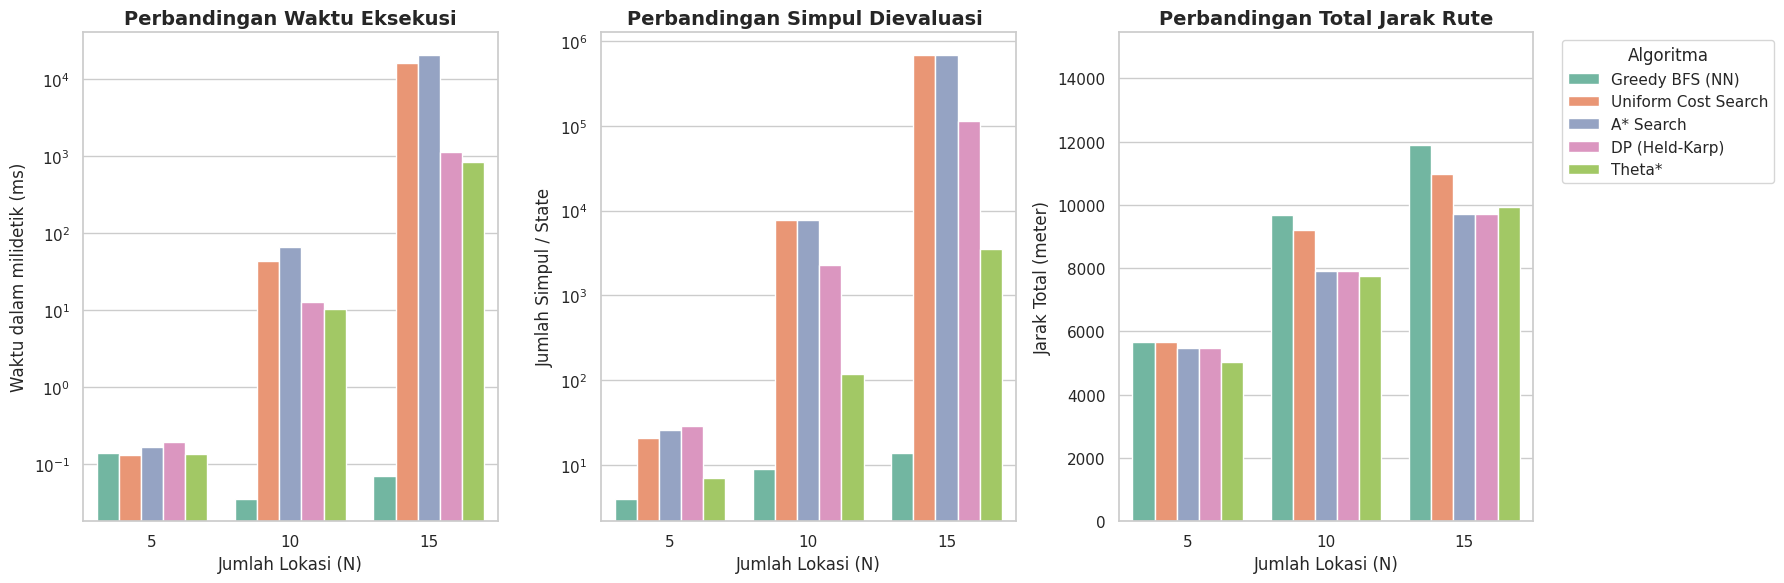

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# MODUL 5: VISUALISASI GRAFIK HASIL EKSPERIMEN (BAR CHART)
# =============================================================================



sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Warna palet untuk 5 algoritma
warna_palet = sns.color_palette("Set2", 5)

# ---------------------------------------------------------
# GRAFIK 1: Waktu Komputasi (ms)
# ---------------------------------------------------------
sns.barplot(
    data=df_hasil, x='N', y='Waktu (ms)', hue='Algoritma',
    ax=axes[0], palette=warna_palet
)
axes[0].set_title('Perbandingan Waktu Eksekusi', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Lokasi (N)', fontsize=12)
axes[0].set_ylabel('Waktu dalam milidetik (ms)', fontsize=12)
# Menggunakan skala logaritmik karena pertumbuhan waktu eksponensial (sangat tajam di N=15)
axes[0].set_yscale('log')

# ---------------------------------------------------------
# GRAFIK 2: Simpul Dievaluasi / Ruang Pencarian
# ---------------------------------------------------------
sns.barplot(
    data=df_hasil, x='N', y='Simpul Dievaluasi', hue='Algoritma',
    ax=axes[1], palette=warna_palet
)
axes[1].set_title('Perbandingan Simpul Dievaluasi ', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Lokasi (N)', fontsize=12)
axes[1].set_ylabel('Jumlah Simpul / State', fontsize=12)
axes[1].set_yscale('log') # Skala logaritmik
# ---------------------------------------------------------
# GRAFIK 3: Optimalitas Jarak Rute
# ---------------------------------------------------------
sns.barplot(
    data=df_hasil, x='N', y='Jarak Optimal (m)', hue='Algoritma',
    ax=axes[2], palette=warna_palet
)
axes[2].set_title('Perbandingan Total Jarak Rute', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Jumlah Lokasi (N)', fontsize=12)
axes[2].set_ylabel('Jarak Total (meter)', fontsize=12)
# Menambahkan sedikit ruang di atas grafik agar legenda tidak menutupi bar
axes[2].set_ylim(0, df_hasil['Jarak Optimal (m)'].max() * 1.3)

# Merapikan letak legenda (Hanya tampilkan 1 legenda utama di luar kotak agar bersih)
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].legend(title="Algoritma", bbox_to_anchor=(1.05, 1), loc='upper left')

# Menyesuaikan jarak antar grafik
plt.tight_layout()
plt.show()

## Kesimpulan Eksperimen
Berdasarkan hasil pengujian eksperimental terhadap permasalahan pencarian rute wisata (TSP) menggunakan lima variasi algoritma pada berbagai skala ruang pencarian (N = 5, 10, 15), dapat ditarik beberapa kesimpulan utama:

1. **Trade-Off Optimalitas dan Kecepatan (Kinerja Greedy):**
   Algoritma *Greedy Best-First Search (Nearest Neighbor)* terbukti memiliki waktu eksekusi paling cepat dan eksplorasi simpul paling sedikit (tumbuh secara linier). Namun, efisiensi ini mengorbankan kualitas solusi; jarak total yang dihasilkan selalu menjadi yang terpanjang (paling sub-optimal) saat ruang pencarian membesar (N=15).

2. **Degradasi Kinerja Heuristik Lemah pada A*:**
   Visualisasi membuktikan bahwa algoritma A* dengan heuristik Euclidean sederhana (jarak ke titik berikutnya) gagal memangkas ruang pencarian secara signifikan. Jumlah simpul yang dievaluasi oleh A* hampir identik dengan pencarian buta (*Uniform Cost Search*), hingga menyentuh ratusan ribu simpul pada N=15. Akibatnya, waktu komputasi A* menjadi yang paling lambat karena adanya *overhead* (beban tambahan) perhitungan heuristik di setiap simpul yang diekspansi.

3. **Keunggulan Dynamic Programming (Held-Karp):**
   Untuk skala kecil hingga menengah (N <= 15), *Dynamic Programming* terbukti menjadi pendekatan yang sangat superior untuk mencari solusi eksak. DP secara konsisten menghasilkan jarak paling optimal (sejajar dengan A*), namun dengan jumlah *state* yang dievaluasi dan waktu eksekusi yang jauh lebih efisien berkat teknik *overlapping subproblems* (penyimpanan memori status).

4. **Efisiensi Heuristik MST pada Theta*:**
   Penggunaan *Minimum Spanning Tree* (MST) sebagai fungsi heuristik pada algoritma Theta* menunjukkan efektivitas pemangkasan (*pruning*) yang luar biasa. Theta* mampu menekan jumlah simpul yang dievaluasi secara drastis dibandingkan A*, menghasilkan waktu komputasi yang sangat cepat, sekaligus menjaga total jarak rute berada di tingkat yang optimal atau sangat mendekati optimal (*near-optimal*).

---

## Matriks Perbandingan Kualitatif

Tabel berikut merangkum karakteristik dan *trade-off* dari masing-masing algoritma berdasarkan grafik komparasi empiris:

| Kategori Evaluasi | Greedy BFS | Uniform Cost Search | A* Search (Heuristik Lemah) | DP (Held-Karp) | Theta* (Heuristik MST) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Optimalitas Jarak** | Sangat Rendah | Sedang / Terbatas | **Sangat Tinggi** (Eksak) | **Sangat Tinggi** (Eksak) | Tinggi (*Near-Optimal*) |
| **Kecepatan Eksekusi** | **Sangat Cepat** | Lambat | Paling Lambat | Cepat | Cepat |
| **Ruang Eksplorasi** | Sangat Minimal | Sangat Masif | Sangat Masif | Terukur (*Bitmask*) | Minimal (*Pruning* Kuat) |
| **Skalabilitas** | **Sangat Baik** | Buruk | Buruk | Terbatas (N <= 20) | Baik |
| **Rekomendasi Penggunaan**| Aplikasi respons cepat yang menoleransi rute panjang. | Baseline evaluasi pencarian tanpa panduan. | Pembelajaran dasar *Informed Search*. | Pencarian rute absolut optimal untuk lokasi terbatas. | Pencarian rute efisien dengan jarak yang kompetitif. |

---
